In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import normalized_mutual_info_score, silhouette_score
from sklearn.preprocessing import LabelEncoder


import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
def purity_score(y_true, y_pred):
    """
    Compute clustering purity score.
    For each cluster, find the majority true label; purity = sum of majority counts / total points.
    Noise points (label == -1) are included in a separate 'noise' cluster.
    """
    from collections import Counter
    total = len(y_true)
    correct = 0
    unique_clusters = set(y_pred)
    for cluster in unique_clusters:
        mask = (y_pred == cluster)
        cluster_labels = y_true[mask]
        if len(cluster_labels) == 0:
            continue
        most_common_count = Counter(cluster_labels).most_common(1)[0][1]
        correct += most_common_count
    return correct / total

print('purity score function define')

purity score function define


In [4]:
# (a) Load the dataset
tsne_df = pd.read_csv('tsne_2d_features_6_languages.csv')
print('Shape:', tsne_df.shape)
print(tsne_df.head())

Shape: (15000, 3)
      tsne_1     tsne_2 language
0  41.288025 -43.939140  Bengali
1  42.584652 -44.717926  Bengali
2  55.583763 -67.719140  Bengali
3  54.196163 -57.556280  Bengali
4  62.459244 -57.051792  Bengali


In [5]:
# (b) Separate features and labels
X = tsne_df[['tsne_1', 'tsne_2']].values
y_true_str = tsne_df['language'].values

le = LabelEncoder()
y_true = le.fit_transform(y_true_str)
languages = le.classes_
print('Languages:', languages)

Languages: ['Bengali' 'English' 'Hindi' 'Kannada' 'Manipuri' 'Marathi']


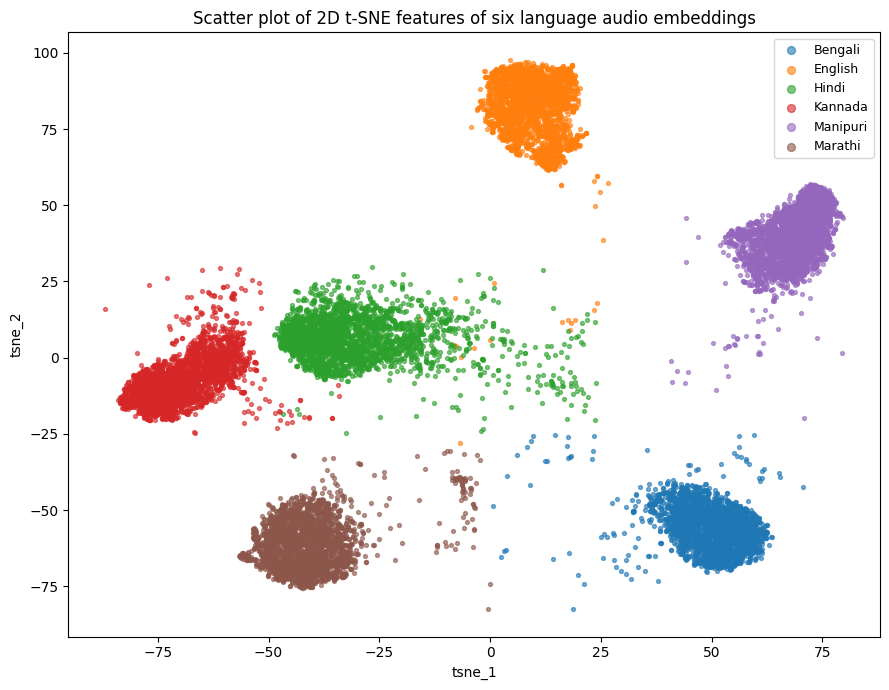

In [6]:
# (c) Visualize dataset — scatter plot with distinct color per language
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

plt.figure(figsize=(9, 7))
for idx, lang in enumerate(languages):
    mask = (y_true_str == lang)
    plt.scatter(X[mask, 0], X[mask, 1], s=8, alpha=0.6,
                color=COLORS[idx], label=lang)
plt.title('Scatter plot of 2D t-SNE features of six language audio embeddings')
plt.xlabel('tsne_1')
plt.ylabel('tsne_2')
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
#Helper function to plot the clusters

def plot_clusters(X, labels, title, filename=None, noise=False):
    unique_labels = sorted(set(labels))
    cmap = cm.get_cmap('tab10', len(unique_labels))
    plt.figure(figsize=(8, 6))
    for i, lbl in enumerate(unique_labels):
        mask = (labels == lbl)
        if noise and lbl == -1:
            plt.scatter(X[mask, 0], X[mask, 1], s=6, c='black',
                        marker='.', alpha=0.4, label='Noise')
        else:
            plt.scatter(X[mask, 0], X[mask, 1], s=10, alpha=0.6,
                        color=cmap(i), label=f'Cluster {lbl}')
    plt.title(title)
    plt.xlabel('tsne_1')
    plt.ylabel('tsne_2')
    plt.legend(markerscale=2, fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


Linkage: WARD
  Purity Score : 0.9911
  NMI          : 0.9741
  Silhouette   : 0.7421


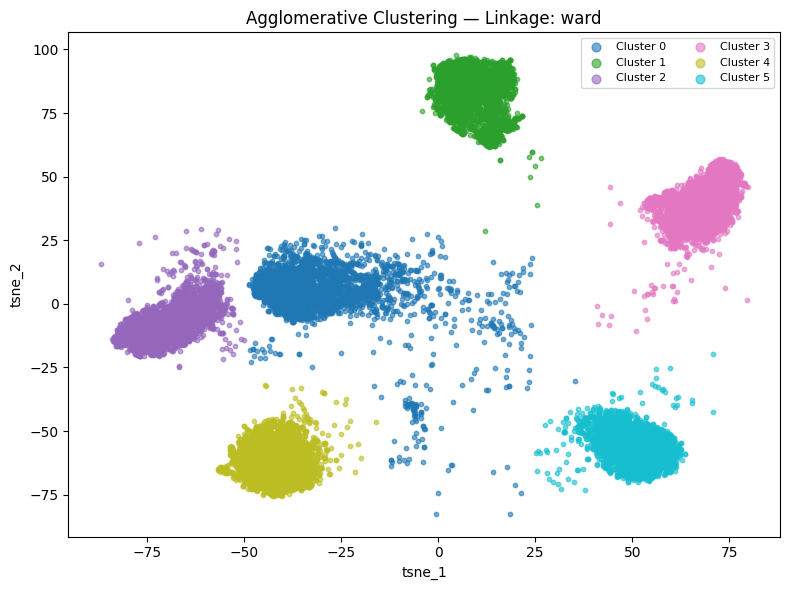


Linkage: COMPLETE
  Purity Score : 0.9915
  NMI          : 0.9724
  Silhouette   : 0.7431


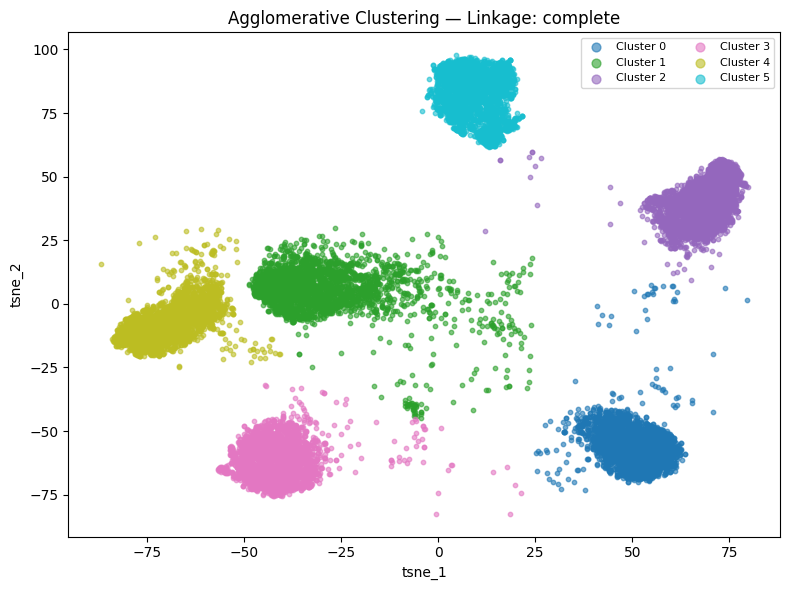


Linkage: AVERAGE
  Purity Score : 0.8387
  NMI          : 0.9136
  Silhouette   : 0.6827


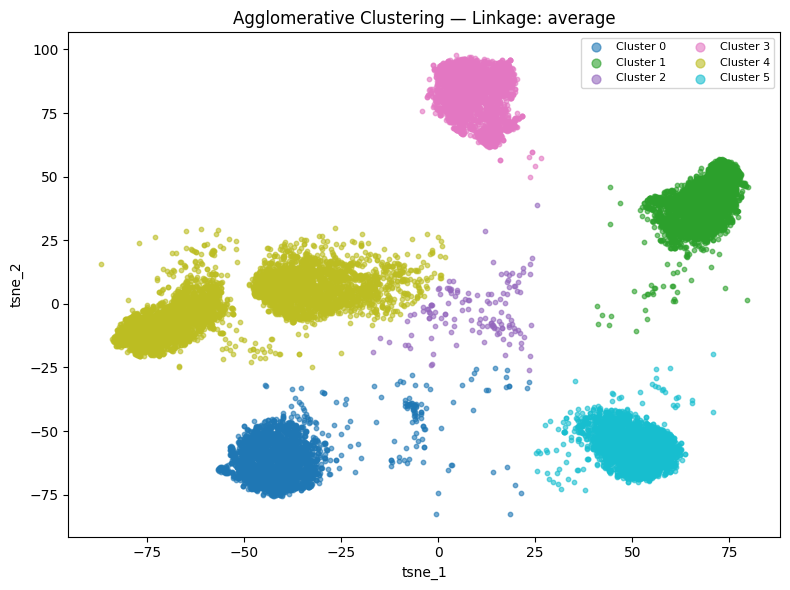


Linkage: SINGLE
  Purity Score : 0.4991
  NMI          : 0.6465
  Silhouette   : 0.0979


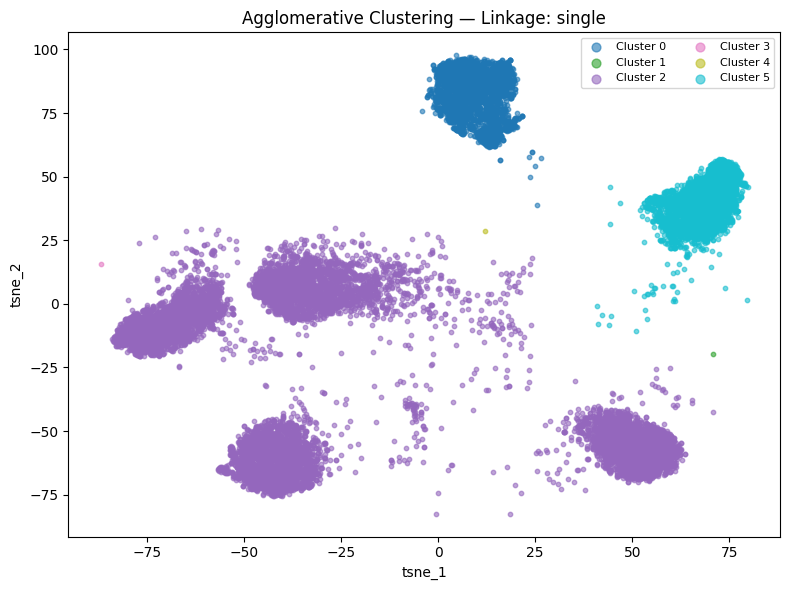

In [8]:
#2d - All four linkage methods

linkage_methods = ['ward', 'complete', 'average', 'single']
hier_results = {}

for linkage in linkage_methods:
    print(f"\n{'='*55}")
    print(f"Linkage: {linkage.upper()}")
    print("="*55)

    # Fit
    model = AgglomerativeClustering(n_clusters=6, linkage=linkage)
    labels = model.fit_predict(X)

    # Metrics
    purity = purity_score(y_true, labels)
    nmi    = normalized_mutual_info_score(y_true, labels)
    sil    = silhouette_score(X, labels)

    hier_results[linkage] = {'Purity': purity, 'NMI': nmi, 'Silhouette': sil, 'labels': labels}
    print(f'  Purity Score : {purity:.4f}')
    print(f'  NMI          : {nmi:.4f}')
    print(f'  Silhouette   : {sil:.4f}')

    # Visualize
    plot_clusters(X, labels,
                  title=f'Agglomerative Clustering — Linkage: {linkage}',
                  filename=f'fig_hier_{linkage}.png')

In [9]:
# Comparison table between linkage methods, dendrogram, and threshold analysis
print('\n Linkage Method Comparison:')
print(f"{'Linkage':<12} {'Purity':>10} {'NMI':>10} {'Silhouette':>12}")
print('-' * 46)
for lm in linkage_methods:
    r = hier_results[lm]
    print(f"{lm:<12} {r['Purity']:>10.4f} {r['NMI']:>10.4f} {r['Silhouette']:>12.4f}")

# Identify best linkage
best_linkage = max(linkage_methods,
                   key=lambda lm: (
                       hier_results[lm]['Purity'] +
                       hier_results[lm]['NMI'] +
                       hier_results[lm]['Silhouette']
                   ))
print(f'\nBest linkage method (by sum of metrics): {best_linkage.upper()}')


 Linkage Method Comparison:
Linkage          Purity        NMI   Silhouette
----------------------------------------------
ward             0.9911     0.9741       0.7421
complete         0.9915     0.9724       0.7431
average          0.8387     0.9136       0.6827
single           0.4991     0.6465       0.0979

Best linkage method (by sum of metrics): WARD


Max linkage distance : 8854.09
60% threshold        : 5312.46


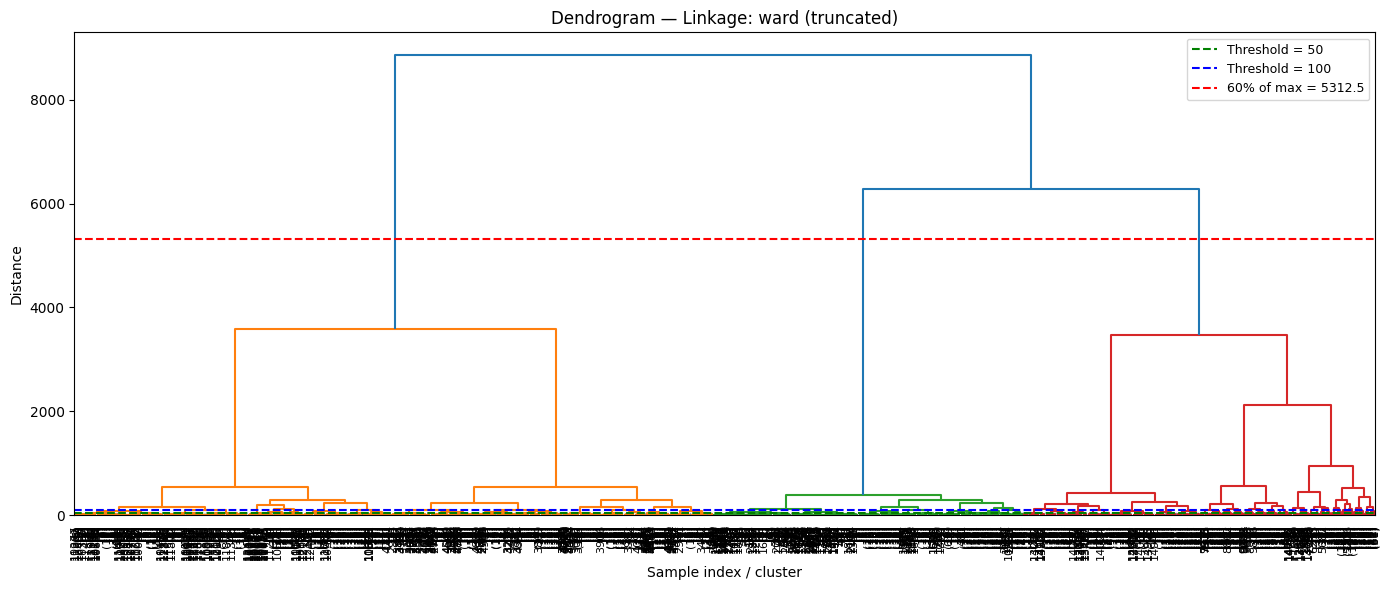

In [10]:
# Dendrogram with best linkage + threshold analysis
linked = sch.linkage(X, method=best_linkage)

# Thresholds
thresh_1 = 50
thresh_2 = 100
max_dist = np.max(linked[:, 2])
thresh_3 = 0.60 * max_dist
print(f'Max linkage distance : {max_dist:.2f}')
print(f'60% threshold        : {thresh_3:.2f}')

plt.figure(figsize=(14, 6))
sch.dendrogram(
    linked,
    truncate_mode='level',
    p=10,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True
)
plt.axhline(y=thresh_1, color='green',  linestyle='--', linewidth=1.5, label=f'Threshold = {thresh_1}')
plt.axhline(y=thresh_2, color='blue',   linestyle='--', linewidth=1.5, label=f'Threshold = {thresh_2}')
plt.axhline(y=thresh_3, color='red',    linestyle='--', linewidth=1.5, label=f'60% of max = {thresh_3:.1f}')
plt.title(f'Dendrogram — Linkage: {best_linkage} (truncated)')
plt.xlabel('Sample index / cluster')
plt.ylabel('Distance')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
# Count clusters formed at each threshold
def count_clusters_at_threshold(linked, threshold):
    labels = sch.fcluster(linked, t=threshold, criterion='distance')
    return len(set(labels))

for t, name in [(thresh_1, '50'), (thresh_2, '100'), (thresh_3, '60% of max')]:
    nc = count_clusters_at_threshold(linked, t)
    print(f'Threshold {name:>12}  →  {nc} cluster(s)')

Threshold           50  →  113 cluster(s)
Threshold          100  →  55 cluster(s)
Threshold   60% of max  →  3 cluster(s)


In [12]:
#Comparing these results with those obtained using K-means and K-Medoids cluster-ing 

comparison_data = {
    'Method':          ['K-Means (Lab 12)', 'K-Medoids (Lab 12)',
                        'Hier. Ward', 'Hier. Complete',
                        'Hier. Average', 'Hier. Single'],
    'Purity Score':    [0.9961, 0.9950,
                        hier_results['ward']['Purity'],
                        hier_results['complete']['Purity'],
                        hier_results['average']['Purity'],
                        hier_results['single']['Purity']],
    'NMI':             [0.9856, 0.9826,
                        hier_results['ward']['NMI'],
                        hier_results['complete']['NMI'],
                        hier_results['average']['NMI'],
                        hier_results['single']['NMI']],
    'Silhouette':      [0.7485, 0.7483,
                        hier_results['ward']['Silhouette'],
                        hier_results['complete']['Silhouette'],
                        hier_results['average']['Silhouette'],
                        hier_results['single']['Silhouette']]
}

comp_df = pd.DataFrame(comparison_data)
print(comp_df.to_string(index=False, float_format=lambda x: f'{x:.4f}' if x is not None else 'N/A'))

            Method  Purity Score    NMI  Silhouette
  K-Means (Lab 12)        0.9961 0.9856      0.7485
K-Medoids (Lab 12)        0.9950 0.9826      0.7483
        Hier. Ward        0.9911 0.9741      0.7421
    Hier. Complete        0.9915 0.9724      0.7431
     Hier. Average        0.8387 0.9136      0.6827
      Hier. Single        0.4991 0.6465      0.0979


In [14]:
#DBSCAN Clustering
from sklearn.cluster import AgglomerativeClustering, DBSCAN

min_samples_values = [5, 10, 15, 20, 25]
eps_values         = [2, 3, 5, 6, 7, 8]

dbscan_results = []
print("started")

for min_samples in min_samples_values:
    for eps in eps_values:
        model  = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X)

        n_clusters  = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise     = np.sum(labels == -1)

        row = {
            'eps': eps, 'min_samples': min_samples,
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'Purity': None, 'NMI': None, 'Silhouette': None,
            'labels': labels
        }

        if n_clusters > 1:
            row['Purity']     = purity_score(y_true, labels)
            row['NMI']        = normalized_mutual_info_score(y_true, labels)
            row['Silhouette'] = silhouette_score(X, labels)

        dbscan_results.append(row)

print(f"{'eps':>5} {'min_s':>6} {'k':>4} {'noise':>7} {'Purity':>9} {'NMI':>9} {'Sil':>9}")
print('-' * 55)
for r in dbscan_results:
    p  = f"{r['Purity']:.4f}"    if r['Purity']     is not None else '  N/A   '
    n  = f"{r['NMI']:.4f}"       if r['NMI']        is not None else '  N/A   '
    s  = f"{r['Silhouette']:.4f}" if r['Silhouette'] is not None else '  N/A   '
    print(f"{r['eps']:>5} {r['min_samples']:>6} {r['n_clusters']:>4} {r['n_noise']:>7} {p:>9} {n:>9} {s:>9}")

started
  eps  min_s    k   noise    Purity       NMI       Sil
-------------------------------------------------------
    2      5   23     359    0.9835    0.9387    0.4327
    3      5   19     188    0.9899    0.9513    0.5038
    5      5   14      63    0.9957    0.9742    0.5447
    6      5   10      38    0.9967    0.9798    0.6280
    7      5    8      25    0.8305    0.9117    0.5990
    8      5    5      13    0.6639    0.8053    0.6199
    2     10    9     585    0.9760    0.9350    0.6659
    3     10   12     356    0.9826    0.9454    0.6214
    5     10    9     142    0.9927    0.9690    0.6320
    6     10    9      85    0.9949    0.9743    0.6367
    7     10    7      63    0.8299    0.9109    0.6625
    8     10    6      40    0.8305    0.9179    0.6803
    2     15    8     734    0.9729    0.9247    0.6477
    3     15    8     455    0.9797    0.9439    0.6950
    5     15    9     224    0.9885    0.9601    0.6597
    6     15    8     149    0.9925    0

In [15]:
# Identify best parameter combination
valid = [r for r in dbscan_results if r['Purity'] is not None]

best = max(valid, key=lambda r: r['Purity'] + r['NMI'] + r['Silhouette'])
print(f"Best DBSCAN params: eps={best['eps']}, min_samples={best['min_samples']}")
print(f"  Clusters  : {best['n_clusters']}")
print(f"  Noise pts : {best['n_noise']}")
print(f"  Purity    : {best['Purity']:.4f}")
print(f"  NMI       : {best['NMI']:.4f}")
print(f"  Silhouette: {best['Silhouette']:.4f}")

Best DBSCAN params: eps=6, min_samples=25
  Clusters  : 8
  Noise pts : 241
  Purity    : 0.9874
  NMI       : 0.9604
  Silhouette: 0.7051


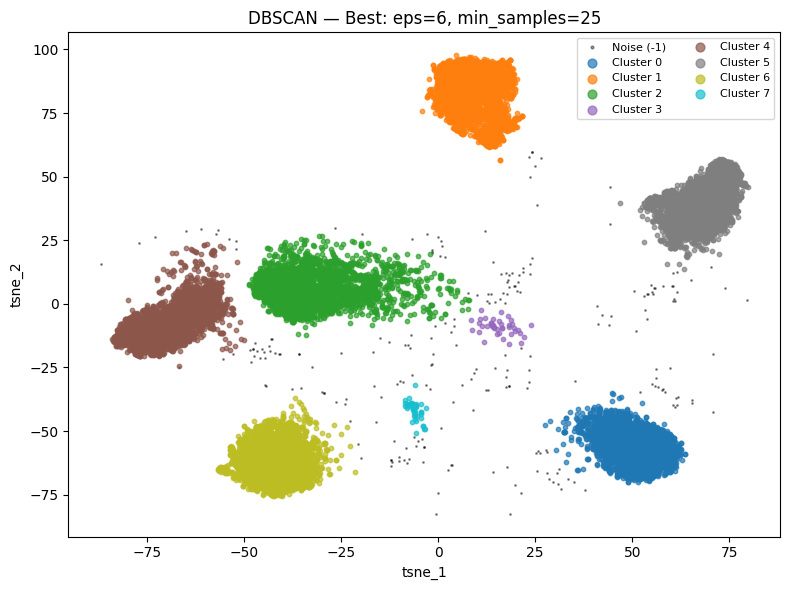

In [17]:
# Visualize best DBSCAN result
best_labels = best['labels']
unique_labels = sorted(set(best_labels))
cmap = cm.get_cmap('tab10', len([l for l in unique_labels if l != -1]))

plt.figure(figsize=(8, 6))
color_idx = 0
for lbl in unique_labels:
    mask = (best_labels == lbl)
    if lbl == -1:
        plt.scatter(X[mask, 0], X[mask, 1], s=4, c='black',
                    marker='.', alpha=0.4, label='Noise (-1)')
    else:
        plt.scatter(X[mask, 0], X[mask, 1], s=10, alpha=0.7,
                    color=cmap(color_idx), label=f'Cluster {lbl}')
        color_idx += 1

plt.title(f"DBSCAN — Best: eps={best['eps']}, min_samples={best['min_samples']}")
plt.xlabel('tsne_1')
plt.ylabel('tsne_2')
plt.legend(markerscale=2, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

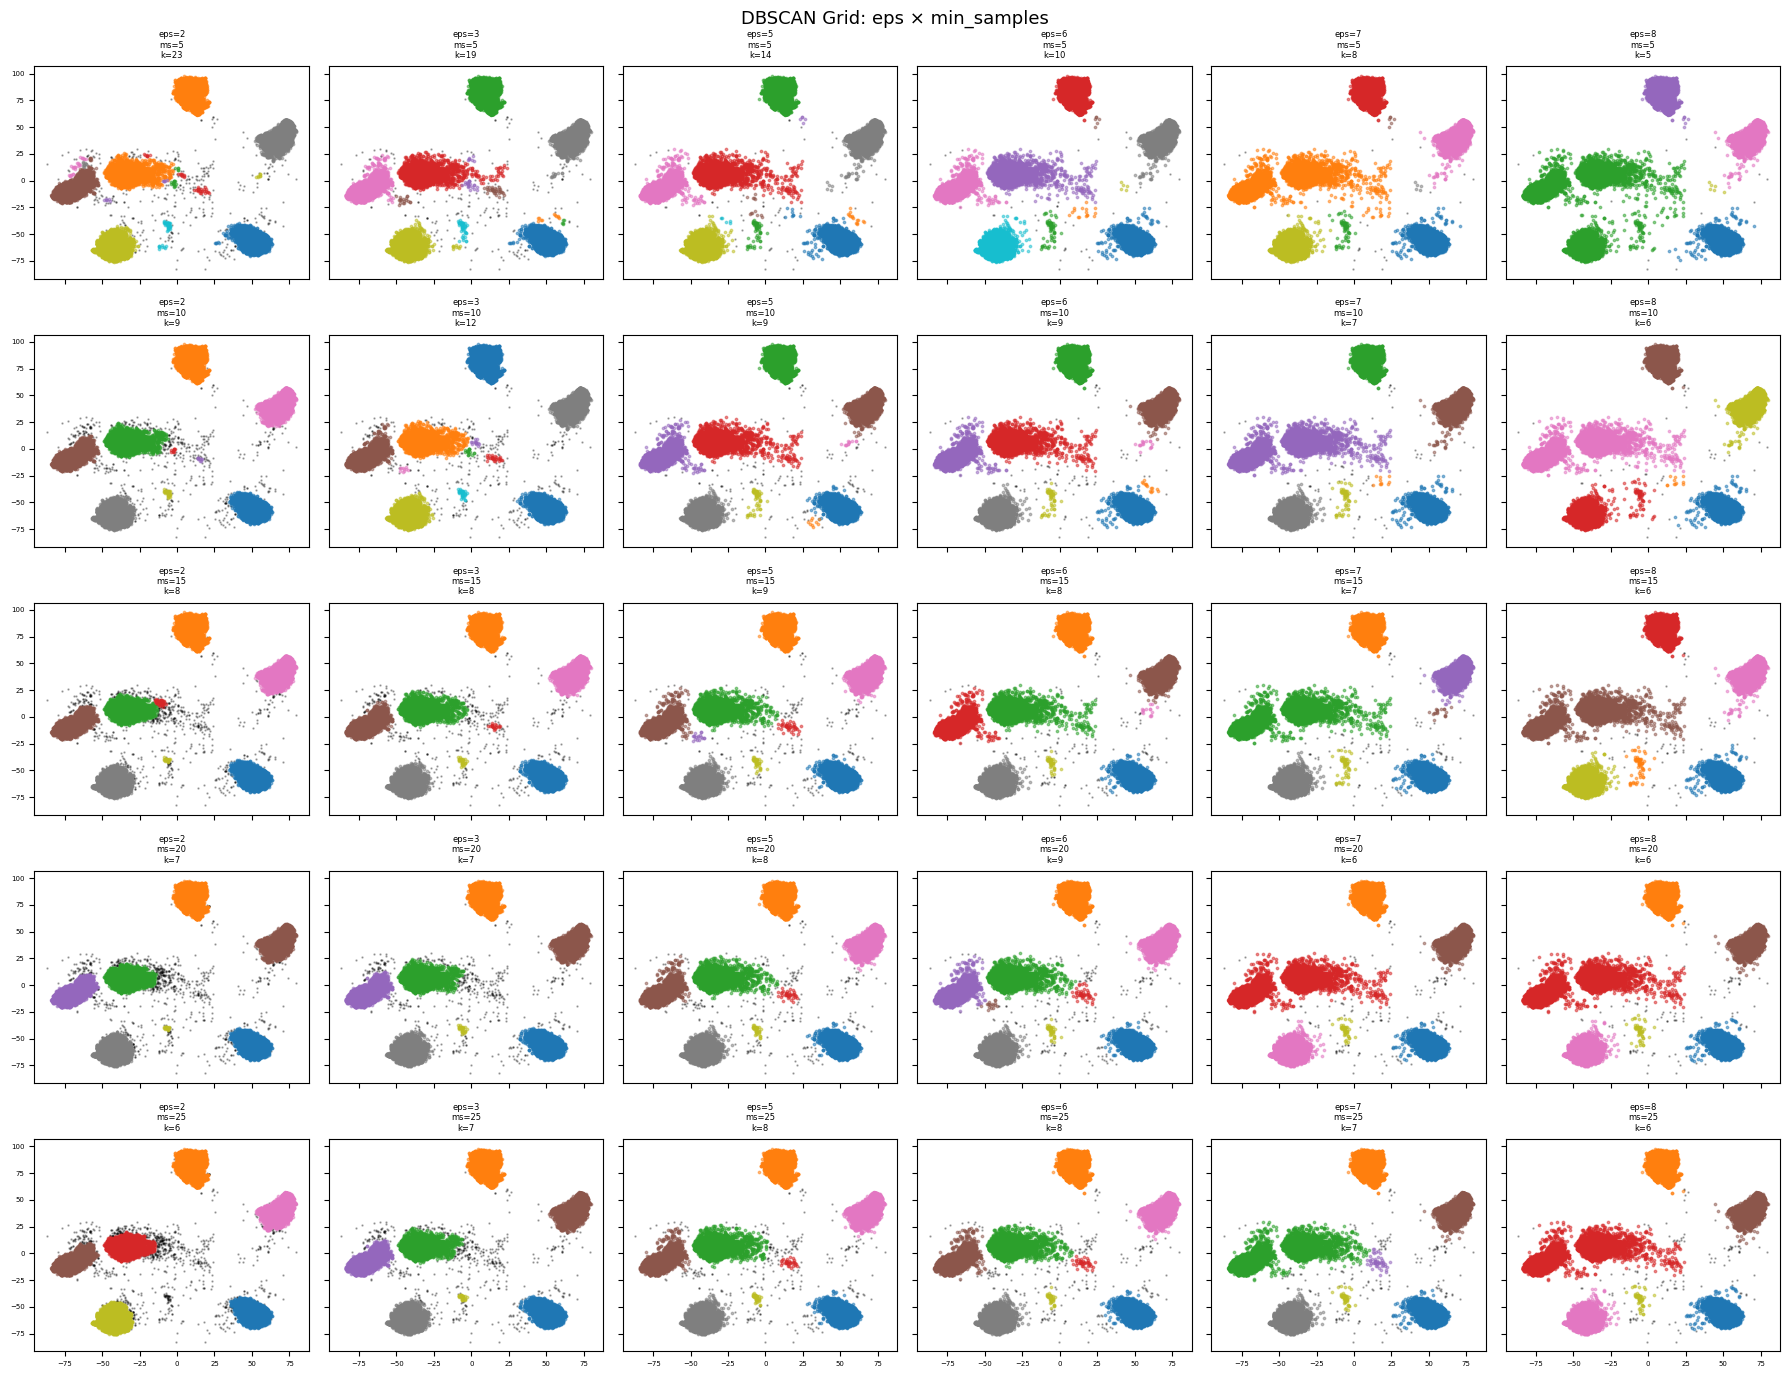

In [18]:
# Visualize all DBSCAN combos in a grid (eps × min_samples)
fig, axes = plt.subplots(len(min_samples_values), len(eps_values),
                         figsize=(18, 14), sharex=True, sharey=True)
idx = 0
for i, ms in enumerate(min_samples_values):
    for j, eps in enumerate(eps_values):
        r = dbscan_results[idx]
        ax = axes[i][j]
        lbl = r['labels']
        unique = sorted(set(lbl))
        cmap2 = cm.get_cmap('tab10', max(len(unique), 2))
        ci = 0
        for u in unique:
            mask = (lbl == u)
            if u == -1:
                ax.scatter(X[mask, 0], X[mask, 1], s=2, c='black', marker='.', alpha=0.3)
            else:
                ax.scatter(X[mask, 0], X[mask, 1], s=3, alpha=0.5, color=cmap2(ci))
                ci += 1
        ax.set_title(f'eps={eps}\nms={ms}\nk={r["n_clusters"]}', fontsize=6)
        ax.tick_params(labelsize=5)
        idx += 1

fig.suptitle('DBSCAN Grid: eps × min_samples', fontsize=13)
plt.tight_layout()
plt.savefig('fig_dbscan_grid.png', dpi=100)
plt.show()

In [21]:
# Build final comparison table
final_rows = [
    # Fill in K-means / K-Medoids from Lab 12
    {'Method': 'K-Means (Lab 12)',         'Purity': 0.9961, 'NMI': 0.9856, 'Silhouette': 0.7485},
    {'Method': 'K-Medoids (Lab 12)',        'Purity': 0.9950, 'NMI': 0.9826, 'Silhouette': 0.7483},
    {'Method': 'Hier. Ward',               'Purity': hier_results['ward']['Purity'],
                                            'NMI': hier_results['ward']['NMI'],
                                            'Silhouette': hier_results['ward']['Silhouette']},
    {'Method': 'Hier. Complete',           'Purity': hier_results['complete']['Purity'],
                                            'NMI': hier_results['complete']['NMI'],
                                            'Silhouette': hier_results['complete']['Silhouette']},
    {'Method': 'Hier. Average',            'Purity': hier_results['average']['Purity'],
                                            'NMI': hier_results['average']['NMI'],
                                            'Silhouette': hier_results['average']['Silhouette']},
    {'Method': 'Hier. Single',             'Purity': hier_results['single']['Purity'],
                                            'NMI': hier_results['single']['NMI'],
                                            'Silhouette': hier_results['single']['Silhouette']},
    {'Method': f"DBSCAN (eps={best['eps']}, ms={best['min_samples']})",
                                            'Purity': best['Purity'],
                                            'NMI': best['NMI'],
                                            'Silhouette': best['Silhouette']},
]

final_df = pd.DataFrame(final_rows)

def fmt(v):
    return f'{v:.4f}' if v is not None else 'N/A (fill from Lab 12)'

print(f"{'Method':<38} {'Purity':>8} {'NMI':>8} {'Silhouette':>10}")
print('-' * 66)
for _, row in final_df.iterrows():
    print(f"{row['Method']:<38} {fmt(row['Purity']):>8} {fmt(row['NMI']):>8} {fmt(row['Silhouette']):>10}")

print()


Method                                   Purity      NMI Silhouette
------------------------------------------------------------------
K-Means (Lab 12)                         0.9961   0.9856     0.7485
K-Medoids (Lab 12)                       0.9950   0.9826     0.7483
Hier. Ward                               0.9911   0.9741     0.7421
Hier. Complete                           0.9915   0.9724     0.7431
Hier. Average                            0.8387   0.9136     0.6827
Hier. Single                             0.4991   0.6465     0.0979
DBSCAN (eps=6, ms=25)                    0.9874   0.9604     0.7051

